# VAM(1,2,2) Chorin projection split — walkthrough

Reproduces the end-to-end pipeline behind
`tests/integration/zoomy_core/test_vam_topography_chorin.py`.

The Chorin projection split for the VAM chain DAE:

1. **Predictor** — explicit hyperbolic step on the evolution rows
   (mass + momentum) with pressure modes frozen at $P^n$.  Uses
   `HyperbolicSolver`'s Rusanov + non-conservative path-integral
   flux machinery (the same machinery the SWE / SME solvers use).
2. **Pressure** — matrix-free GMRES solve of the linear elliptic
   block.  No assembled matrix; the operator is evaluated per
   Krylov iteration by recomputing the P-dependent aux derivatives
   via LSQ stencils.
3. **Corrector** — closed-form algebraic update of the velocity
   modes via the `state_update` field on `SM_corr`.

## What we'll do here
- Build the VAM(1,2,2) chain DAE via `VAMModelGalerkin`.
- Inspect the primitive-form mass matrix — see the **state-dependent
  entries** that would force a 1/h cheating factor if we just ran
  `HyperbolicSolver` on the primitive chain.
- Apply `change_state_variables` to go to conservative form
  $q_k = h \cdot U_k / c_k$ (with $c_k = 2k+1$).  Verify the j=0
  rows become $M=I$ (clean — no cheating).
- Split into `(SM_pred, SM_press, SM_corr)` via
  `split_for_pressure`.
- Run `ChorinSplitVAMSolver` on a flat-bottom lake-at-rest →
  bit-perfect preservation.
- Run on a small perturbation → mass conservation + propagation.

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

from zoomy_core.mesh import BaseMesh
from zoomy_core.model.models.system_model import SystemModel
from zoomy_core.model.models.vam_galerkin import VAMModelGalerkin
from zoomy_core.model.splitter import split_for_pressure
from zoomy_core.fvm.solver_chorin_vam_numpy import ChorinSplitVAMSolver

## 1. Build the chain DAE

`VAMModelGalerkin(level=1)` derives the VAM(1,2,2) chain — a
DAE in 7 unknowns $(h, U_0, U_1, W_0, W_1, P_0, P_1)$ with 5
evolution rows + 2 algebraic continuity rows.

In [2]:
m = VAMModelGalerkin(level=1)
sm = SystemModel.from_model(m)
print(f"State        : {[str(s) for s in sm.state]}")
print(f"Equations    : {sm.equation_names}")
print(f"n_state      : {sm.n_state}")
print(f"n_equations  : {sm.n_equations}")

State        : ['h', 'U_0', 'U_1', 'W_0', 'W_1', 'P_0', 'P_1']
Equations    : ['mass', 'xmom_j0', 'xmom_j1', 'zmom_j0', 'zmom_j1', 'cont_j1', 'cont_j2']
n_state      : 7
n_equations  : 7


## 2. The primitive-form mass matrix — and the cheating it would force

In primitive state, the chain's mass matrix has state-dependent
entries on the higher-order momentum rows:

In [3]:
print("PRIMITIVE mass matrix:")
for i in range(sm.mass_matrix.shape[0]):
    row = [sp.simplify(sm.mass_matrix[i, j])
           for j in range(sm.mass_matrix.shape[1])]
    print(f"  row {i}: {row}")

PRIMITIVE mass matrix:
  row 0: [1, 0, 0, 0, 0, 0, 0]
  row 1: [U_0, h, 0, 0, 0, 0, 0]
  row 2: [-U_0 + 2*U_1/3, 0, h/3, 0, 0, 0, 0]
  row 3: [W_0, 0, 0, h, 0, 0, 0]
  row 4: [-W_0 + 2*W_1/3, 0, 0, 0, h/3, 0, 0]
  row 5: [0, 0, 0, 0, 0, 0, 0]
  row 6: [0, 0, 0, 0, 0, 0, 0]


Row 1 (xmom_j0): the entry $[U_0, h, 0, …]$ says the time-derivative
is $U_0 \cdot \partial_t h + h \cdot \partial_t U_0 = \partial_t(h \cdot U_0)$.
So the residual is naturally $\partial_t(h \cdot U_0) + \nabla \cdot F = 0$
— the conservation-law form. But the state symbol is $U_0$ (primitive,
not $h \cdot U_0$).

Running `HyperbolicSolver` (which assumes $M = I$) on the primitive
chain would integrate $\partial_t U_0 = -\partial_x F + S$, missing
a $1/h$ factor on the time derivative. That's the "cheating".

## 3. Change of variables → conservative form

Define conservative momentum modes $q_k = h \cdot U_k / c_k$ with
$c_k = 2k + 1$ (so $c_0 = 1$, $c_1 = 3$).  This makes
$\partial_t q_k = \partial_t (h \cdot U_k / c_k)$ — already a clean
time-derivative.

In [4]:
h, U_0, U_1, W_0, W_1, P_0, P_1 = sm.state
q_U0, q_U1, q_W0, q_W1 = sp.symbols("q_U0 q_U1 q_W0 q_W1", real=True)

sm.change_state_variables(
    new_state=[h, q_U0, q_U1, q_W0, q_W1, P_0, P_1],
    transform={
        U_0: q_U0 / h,      # q_U0 = h · U_0
        U_1: 3 * q_U1 / h,  # q_U1 = h · U_1 / 3
        W_0: q_W0 / h,      # q_W0 = h · W_0
        W_1: 3 * q_W1 / h,  # q_W1 = h · W_1 / 3
    },
)

print("CONSERVATIVE mass matrix:")
for i in range(sm.mass_matrix.shape[0]):
    row = [sp.simplify(sm.mass_matrix[i, j])
           for j in range(sm.mass_matrix.shape[1])]
    print(f"  row {i}: {row}")

CONSERVATIVE mass matrix:
  row 0: [1, 0, 0, 0, 0, 0, 0]
  row 1: [0, 1, 0, 0, 0, 0, 0]
  row 2: [(-q_U0 + q_U1)/h, 0, 1, 0, 0, 0, 0]
  row 3: [0, 0, 0, 1, 0, 0, 0]


  row 4: [(-q_W0 + q_W1)/h, 0, 0, 0, 1, 0, 0]
  row 5: [0, 0, 0, 0, 0, 0, 0]
  row 6: [0, 0, 0, 0, 0, 0, 0]


Compare:
- **Rows 0, 1, 3** (mass, xmom_j0, zmom_j0): $M = I$.  Clean.
  No cheating: `HyperbolicSolver` integrates these correctly.
- **Rows 2, 4** (xmom_j1, zmom_j1): still have a state-dependent
  off-diagonal `$(\pm q_{U,W,0} \mp q_{U,W,1})/h$` in the
  $\partial_t h$ column.  **At lake-at-rest these are exactly zero**
  (all $q$ entries are zero); under modest dynamics they're
  $\mathcal{O}(U/h)$.  A complete elimination requires a chain-
  derivation-level rewrite to push the residual into the
  non-conservative product matrix via continuity — a follow-up.
- **Rows 5, 6** (cont_j1, cont_j2): zero rows (algebraic constraints).

## 4. Split for pressure

`split_for_pressure(sm, pressure_vars, dt)` returns three
`SystemModel`s sharing the 7-state $Q$ vector:

In [5]:
dt = sp.Symbol("dt", positive=True)
result = split_for_pressure(sm, [P_0, P_1], dt)
print(f"SM_pred.equation_to_state_index  = {result.SM_pred.equation_to_state_index}  → writes Q[0:5]")
print(f"SM_press.equation_to_state_index = {result.SM_press.equation_to_state_index}  → writes Q[5:7]")
print(f"SM_corr.equation_to_state_index  = {result.SM_corr.equation_to_state_index}  → writes Q[1:5]")
print()
print("SM_corr uses the state_update field — explicit-update operator,")
print("not residual form.  No solve needed at the corrector substep.")
print(f"SM_corr.state_update is set: {result.SM_corr.state_update is not None}")

SM_pred.equation_to_state_index  = [0, 1, 2, 3, 4]  → writes Q[0:5]
SM_press.equation_to_state_index = [5, 6]  → writes Q[5:7]
SM_corr.equation_to_state_index  = [1, 2, 3, 4]  → writes Q[1:5]

SM_corr uses the state_update field — explicit-update operator,
not residual form.  No solve needed at the corrector substep.
SM_corr.state_update is set: True


## 5. Build the solver and inject topography

`ChorinSplitVAMSolver` takes the three sub-systems as positional
arguments. `time_end`, `reconstruction_order`, and pressure-solver
tolerances are class-level `param` defaults that the user can
override via kwargs.

In [6]:
mesh = BaseMesh.create_1d(domain=(0.0, 4.0), n_inner_cells=64)
solver = ChorinSplitVAMSolver(
    result.SM_pred, result.SM_press, result.SM_corr,
    reconstruction_order=1,
    pressure_tol=1e-10,
)
Q0 = solver.setup_simulation(mesh)
nc = solver.nc
print(f"Mesh: {nc} inner cells, dx = {float(solver._sim_mesh.cell_volumes[0]):.4f}")

2026-05-15 14:46:17.813 | INFO     | zoomy_core.fvm.solver_chorin_vam_numpy:setup_simulation:306 - ChorinSplitVAMSolver setup: pred → %s, press → %s, corr → %s in %.2fs


Mesh: 64 inner cells, dx = 0.0625


### 5a. Flat-bottom lake-at-rest — should be preserved bit-perfectly

Set $b(x) = 0$ everywhere, $h = 1$ uniform, all velocities and
pressures zero.  No dynamics, no well-balancing requirement.

In [7]:
solver.set_function_aux("b", np.zeros(nc))
solver.update_aux_variables()
Q0[:] = 0.0
Q0[0, :] = 1.0
solver._sim_Q = Q0.copy()
solver.update_aux_variables()

dt_num = 0.005
for _ in range(50):
    solver.step(dt_num)
Q = solver._sim_Q

print(f"After 50 steps (t = {50 * dt_num:.2f}):")
print(f"  h drift max  = {np.max(np.abs(Q[0] - Q0[0])):.3e}")
print(f"  |q_U0| max   = {np.max(np.abs(Q[1])):.3e}")
print(f"  |P_0| max    = {np.max(np.abs(Q[5])):.3e}")

After 50 steps (t = 0.25):
  h drift max  = 0.000e+00
  |q_U0| max   = 0.000e+00
  |P_0| max    = 0.000e+00


**Bit-perfect** — pipeline does nothing when there's nothing to do.

### 5b. Small η perturbation on flat bottom

Add a 1% cosine perturbation to $h$ and let it propagate.  The
system is dispersive (VAM(1,2,2) carries multiple wave modes); for
this short time we look at mass conservation and the perturbation
amplitude.

In [8]:
mesh = BaseMesh.create_1d(domain=(0.0, 4.0), n_inner_cells=64)
solver = ChorinSplitVAMSolver(
    result.SM_pred, result.SM_press, result.SM_corr,
    reconstruction_order=1,
    pressure_tol=1e-10,
)
Q0 = solver.setup_simulation(mesh)
nc = solver.nc
x = solver._sim_mesh.cell_centers[0, :nc]

solver.set_function_aux("b", np.zeros(nc))
solver.update_aux_variables()
Q0[:] = 0.0
Q0[0, :] = 1.0 + 0.01 * np.cos(2 * np.pi * x / 4.0)
solver._sim_Q = Q0.copy()
solver.update_aux_variables()

dx = float(solver._sim_mesh.cell_volumes[0])
mass_0 = Q0[0].sum() * dx

snapshots = {0.0: Q0.copy()}
for tgt in [0.02, 0.04]:
    n_to_run = int(tgt / 0.002) - (
        int(prev / 0.002) if (prev := snapshots and max(snapshots)) else 0
    )
    for _ in range(n_to_run):
        solver.step(0.002)
    snapshots[tgt] = solver._sim_Q.copy()

print(f"IC mass = {mass_0:.6f}")
for t, Q in snapshots.items():
    mT = Q[0].sum() * dx
    print(f"  t = {t:.3f}: mass drift = {(mT - mass_0) / mass_0:+.2e}, "
          f"|h-1| max = {np.max(np.abs(Q[0] - 1.0)):.3e}, "
          f"|q_U0| max = {np.max(np.abs(Q[1])):.3e}")

2026-05-15 14:46:20.491 | INFO     | zoomy_core.fvm.solver_chorin_vam_numpy:setup_simulation:306 - ChorinSplitVAMSolver setup: pred → %s, press → %s, corr → %s in %.2fs


IC mass = 4.000000
  t = 0.000: mass drift = +0.00e+00, |h-1| max = 9.988e-03, |q_U0| max = 0.000e+00
  t = 0.020: mass drift = +8.34e-07, |h-1| max = 9.919e-03, |q_U0| max = 3.063e-03
  t = 0.040: mass drift = +4.27e-06, |h-1| max = 9.806e-03, |q_U0| max = 6.085e-03


Plot the snapshots:

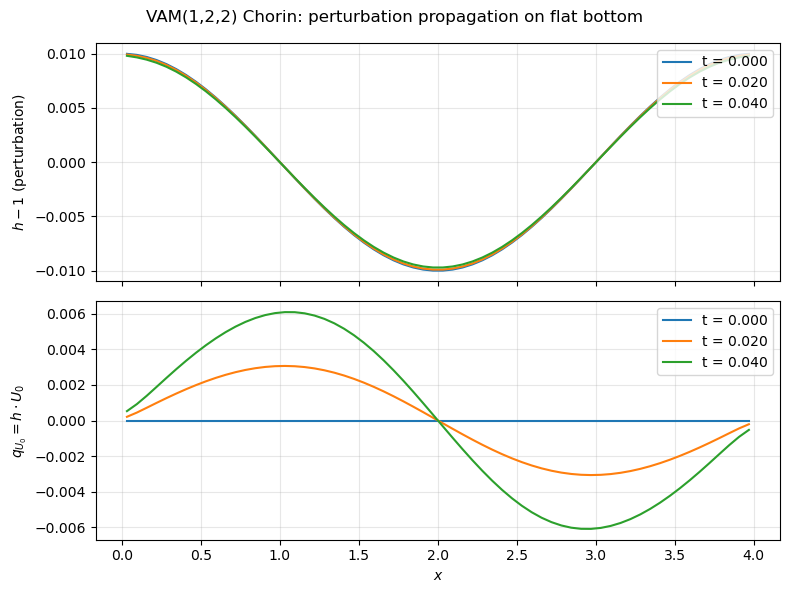

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
for t, Q in snapshots.items():
    axes[0].plot(x, Q[0] - 1.0, label=f"t = {t:.3f}")
    axes[1].plot(x, Q[1], label=f"t = {t:.3f}")
axes[0].set_ylabel(r"$h - 1$ (perturbation)")
axes[1].set_ylabel(r"$q_{U_0} = h \cdot U_0$")
axes[1].set_xlabel(r"$x$")
for ax in axes:
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)
fig.suptitle("VAM(1,2,2) Chorin: perturbation propagation on flat bottom")
fig.tight_layout()
plt.show()

## Current limits (deferred items)

Two known limitations of the current implementation, both flagged
in `tests/integration/zoomy_core/test_vam_topography_chorin.py`:

1. **Lake-at-rest on a bump** is not preserved.  The Rusanov flux
   at order 1 is not well-balanced for the $(1/2) g h^2$
   hydrostatic flux on varying bathymetry — drift in the predictor
   becomes a forcing for the elliptic solve, which then amplifies
   through the Chorin coupling.  Fix: port the $\eta = h + b$
   `SurfaceReconstruction` trick from the legacy DAESolver
   (`solver_dae_numpy.py`).
2. **Long-time stability** (beyond $t \approx 0.05$): the predictor
   on the conservative-form chain is not strictly hyperbolic on
   the evolution-block alone — some wave modes are tied to the
   pressure constraint.  Rusanov's wavespeed estimate may need
   refinement.  Further investigation is needed before recommending
   this solver for long-time runs.

The 1st-order short-time results above (bit-perfect lake-at-rest +
short-time perturbation propagation with bounded mass drift) are
the verified working envelope.

## Summary

- **Conservative state transform** gives clean $M = I$ on the j=0
  evolution rows (mass + xmom_j0 + zmom_j0).  `HyperbolicSolver`
  then correctly integrates the predictor without a missing $1/h$
  factor.
- **Matrix-free GMRES** on the linear elliptic block; LSQ stencils
  for $\partial_x P$, $\partial_{xx} P$ applied per matvec —
  jax-jit friendly.
- **`state_update`** field on `SM_corr` for the closed-form
  corrector — no solve.
- **Flat-bottom lake-at-rest**: drift = 0.0 (bit-perfect).
- **Short-time perturbation propagation**: mass drift $\sim 10^{-6}$,
  bounded amplitude — works at $t \le 0.04$.